# Análisis individual de un run

Este notebook explora un único run del binario `MonitorSystemCplusplus` y
genera la batería completa de gráficas que caracterizan su comportamiento:
fases del prompt, evolución de hardware, correlaciones, distribuciones de
inferencia y confianza del modelo.

Es el primer notebook de la suite del TFG (`01_*`). Los siguientes notebooks
(`02_*`, `03_*`, `04_*`) construyen sobre estos mismos bloques pero aplicados
a colecciones de varios runs.

## Cómo usar este notebook

1. Coloca un run en `data/raw_runs/` (carpeta con `resumen.json`,
   `*_prompt_metrics_*.jsonl` y opcionalmente `*_hw_metrics_*.jsonl`).
2. Edita la variable `RUN_PATH` en la siguiente celda.
3. *Run All*.

In [1]:
"""Configuración del análisis. Edita RUN_PATH antes de ejecutar."""

from pathlib import Path

# --- Parámetros del análisis ---------------------------------------------
# Detectar la raíz del proyecto de forma robusta
_here = Path.cwd()
if _here.name == "notebooks":
    PROJECT_ROOT = _here.parent
else:
    PROJECT_ROOT = _here

RUN_PATH = PROJECT_ROOT / "data" / "raw_runs" / "gemma"

# Activa/desactiva secciones específicas del notebook.
SHOW_TIMELINE = True
SHOW_MEMORY = True
SHOW_DUAL_AXIS = True
SHOW_DISTRIBUTIONS = True
SHOW_LOGPROB = True
SHOW_PER_CORE_FREQ = True

# --- Imports -------------------------------------------------------------

import warnings

import matplotlib.pyplot as plt
import pandas as pd

from monitorviz.io import load_run
from monitorviz.transforms import (
    hw_freq_long,
    hw_metrics_to_df,
    prompt_metrics_to_df,
    tokens_to_df,
)
from monitorviz.viz import (
    cpu_memory_dual,
    hw_freq_panel,
    hw_timeline,
    inference_summary_panel,
    logprob_panel,
    memory_timeline,
    setup_style,
    temp_power_dual,
)

# Estilo del proyecto
setup_style("talk")

# Mostrar más columnas en pandas
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

# Silenciar warnings irrelevantes de matplotlib/seaborn
warnings.filterwarnings("ignore", category=UserWarning, module="seaborn")

assert RUN_PATH.is_dir(), (
    f"❌ No encontrado: {RUN_PATH.resolve()}\n"
    "Asegúrate de que el directorio existe y contiene resumen.json."
)
print(f"✅ Run encontrado en: {RUN_PATH.resolve()}")

✅ Run encontrado en: /home/yisus/PycharmProjects/Visualizer/data/raw_runs/gemma


## 1. Carga y metadatos

Cargamos el run y mostramos su metadata: motor de inferencia, modelo,
configuración, duración y número de prompts.

In [2]:
run = load_run(RUN_PATH)

duration_s = (
    run.summary.timestamp_run_end_ns - run.summary.timestamp_run_start_ns
) / 1e9

metadata = {
    "Run ID": run.run_id,
    "Motor": run.summary.inference_engine,
    "Modelo": run.model_short,
    "Tipo de test": run.summary.test_type,
    "Duración total": f"{duration_s:.1f} s",
    "Nº de prompts": run.summary.num_prompts,
    "Batch size": run.summary.batch_size,
    "Context size": run.summary.context_size,
    "Seed": run.summary.seed,
    "Temperatura": run.summary.temperature,
    "Periodo de muestreo HW": f"{run.summary.hardware_period_s} s",
    "Hay datos de HW": "sí" if run.has_hardware_data else "no",
    "Ventilador": run.meta.fan,
    "Acelerador": run.meta.accelerator,
    "Notas": run.meta.notes or "—",
}

if run.summary.annotations:
    metadata["Anotaciones del binario"] = run.summary.annotations

pd.DataFrame(metadata.items(), columns=["Atributo", "Valor"]).set_index("Atributo")

,Valor
Atributo,
Run ID,gemma
Motor,OLLAMA
Modelo,gemma3n:e2b
Tipo de test,TYPE_1
Duración total,157.2 s
Nº de prompts,1
Batch size,512
Context size,4096
Seed,42


## 2. Resumen por prompt

Una fila por prompt con sus tiempos en cada fase, métricas de inferencia
(latencia, throughput, perplejidad) y un flag que marca generaciones vacías
(prompts donde el modelo decide no generar nada).

In [3]:
prompt_df = prompt_metrics_to_df(run)

# Convertimos las duraciones de fase a segundos para que la tabla sea legible
prompt_view = prompt_df.assign(
    load_s=prompt_df["load_duration_ns"] / 1e9,
    prefill_s=prompt_df["prompt_eval_duration_ns"] / 1e9,
    decode_s=prompt_df["eval_duration_ns"] / 1e9,
)
prompt_view[
    [
        "prompt_id", "is_empty_generation",
        "load_s", "prefill_s", "decode_s",
        "latency_ms", "time_to_first_token_ms",
        "tokens_per_second", "words_per_second", "perplexity",
        "n_words_answer", "eval_count",
        "t_rel_s",
    ]
].round(3)

,prompt_id,is_empty_generation,load_s,prefill_s,decode_s,latency_ms,time_to_first_token_ms,tokens_per_second,words_per_second,perplexity,n_words_answer,eval_count,t_rel_s
0,0,False,70.442,8.001,73.84,156154.222,78443.597,5.972,4.713,1.226,348,441,0.605


## 3. Datos de hardware

Si el run es TYPE_1 o TYPE_2 hay serie temporal de hardware. Mostramos sus
estadísticos descriptivos para tener una primera idea del régimen térmico
y de potencia.

In [4]:
if not run.has_hardware_data:
    print("Este run no tiene datos de hardware (probablemente TYPE_0).")
    hw_df = pd.DataFrame()
else:
    hw_df = hw_metrics_to_df(run)
    print(f"Muestras de hardware: {len(hw_df)}")
    print(
        f"Periodo medio entre muestras: "
        f"{hw_df['t_rel_s'].diff().dropna().mean():.3f} s"
    )

if not hw_df.empty:
    cols = [
        "temperature_c", "internal_power_w",
        "cpu_usage_pct", "freq_mean_ghz",
        "mem_pct", "swap_pct",
        "fan_rpm", "voltage_v",
    ]
    hw_df[cols].describe().round(2)


Muestras de hardware: 313
Periodo medio entre muestras: 0.500 s


## 4. Timeline general

Vista panorámica del run: fases del prompt arriba, métricas de hardware
abajo. Las líneas rojas verticales marcan momentos de throttling activo.

**Cómo leerlo**:
- Las bandas coloreadas del strip superior muestran las tres fases de cada
  prompt: amarillo `load` (carga del modelo), cyan `prefill` (lectura del
  prompt) y naranja `decode` (generación de tokens). En la mayoría de los
  casos, la fase de `decode` domina visualmente porque es secuencial.
- Las líneas rojas verticales sobre todos los paneles indican muestras con
  alguna flag de throttling activa (`under_voltage`, `freq_capped`,
  `throttled` o `soft_throttled`).
- Si la temperatura supera 80 °C es probable que aparezca `soft_throttled`.

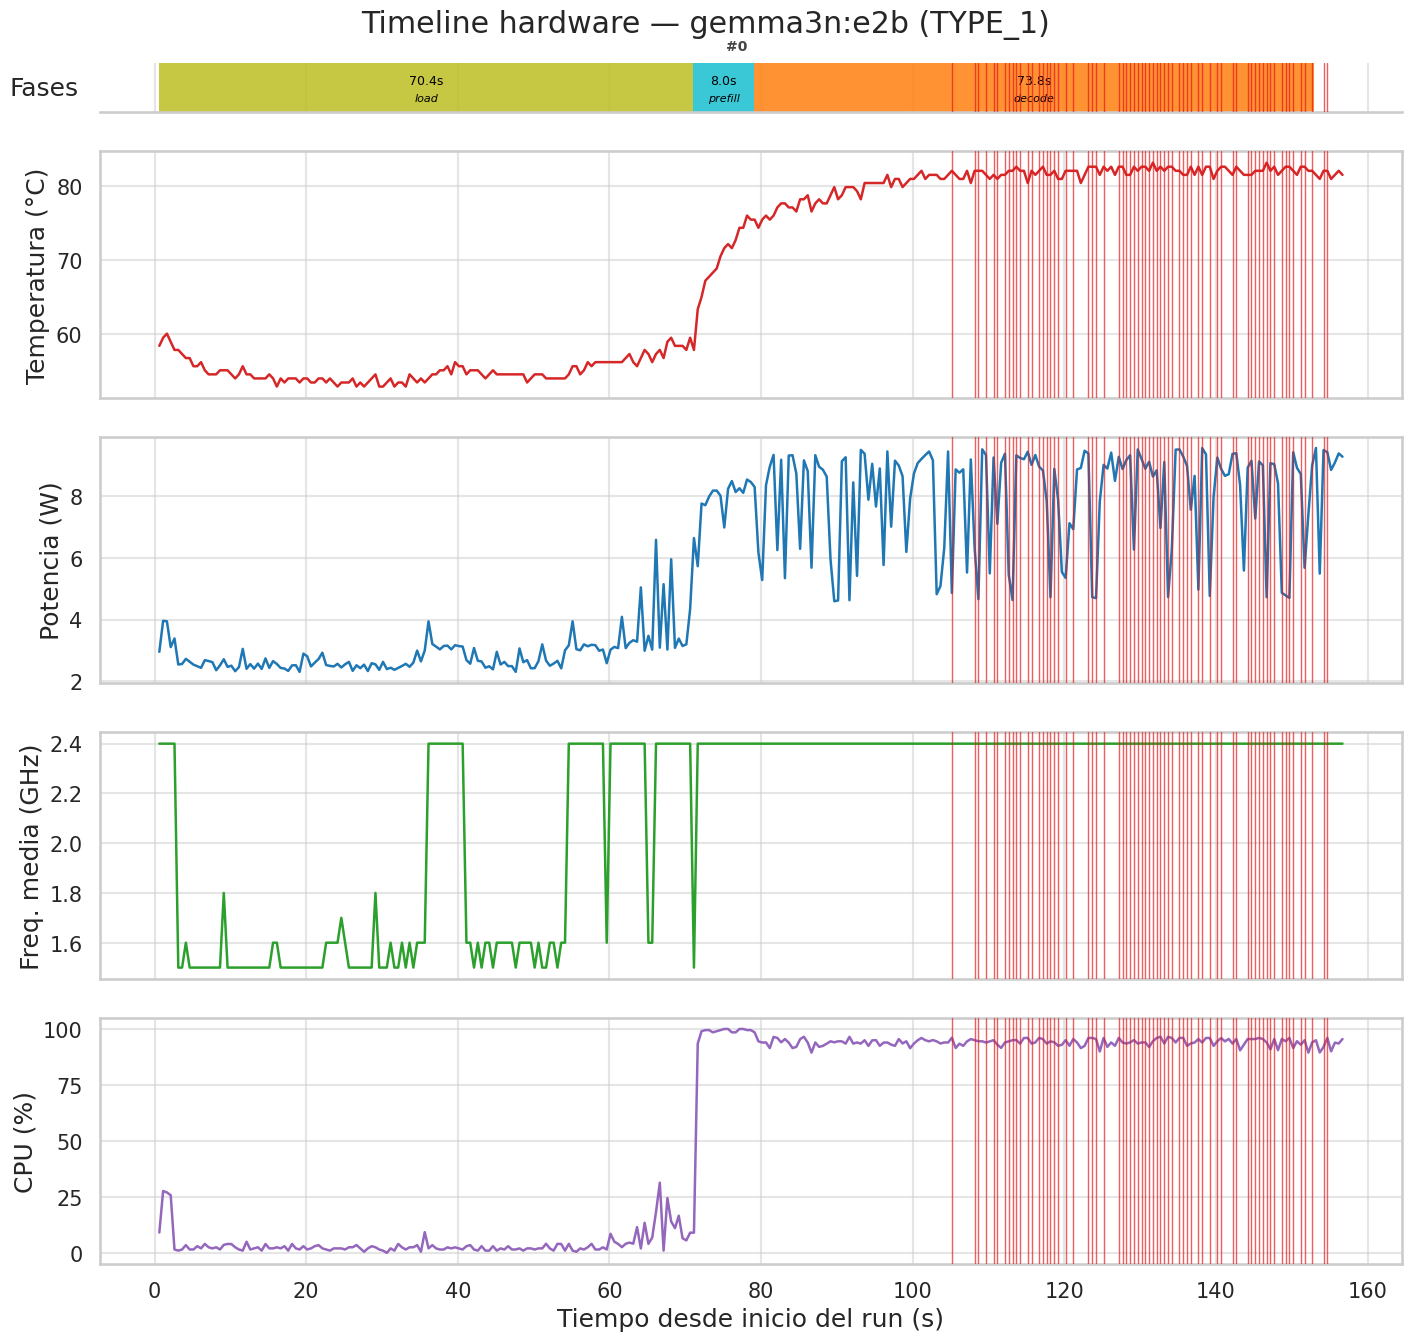

In [5]:
if SHOW_TIMELINE and not hw_df.empty:
    fig = hw_timeline(
        hw_df, prompt_df,
        title=f"Timeline hardware — {run.model_short} ({run.summary.test_type})",
    )
    plt.show()
elif hw_df.empty:
    print("Sin datos de hardware: timeline omitida.")
else:
    print("Timeline desactivada por SHOW_TIMELINE=False.")

## 5. Memoria y swap

Evolución del uso de RAM y swap. Una subida sostenida de swap durante el
decode indica que el modelo no cabe en RAM y el sistema está paginando, lo
cual penaliza dramáticamente el throughput.

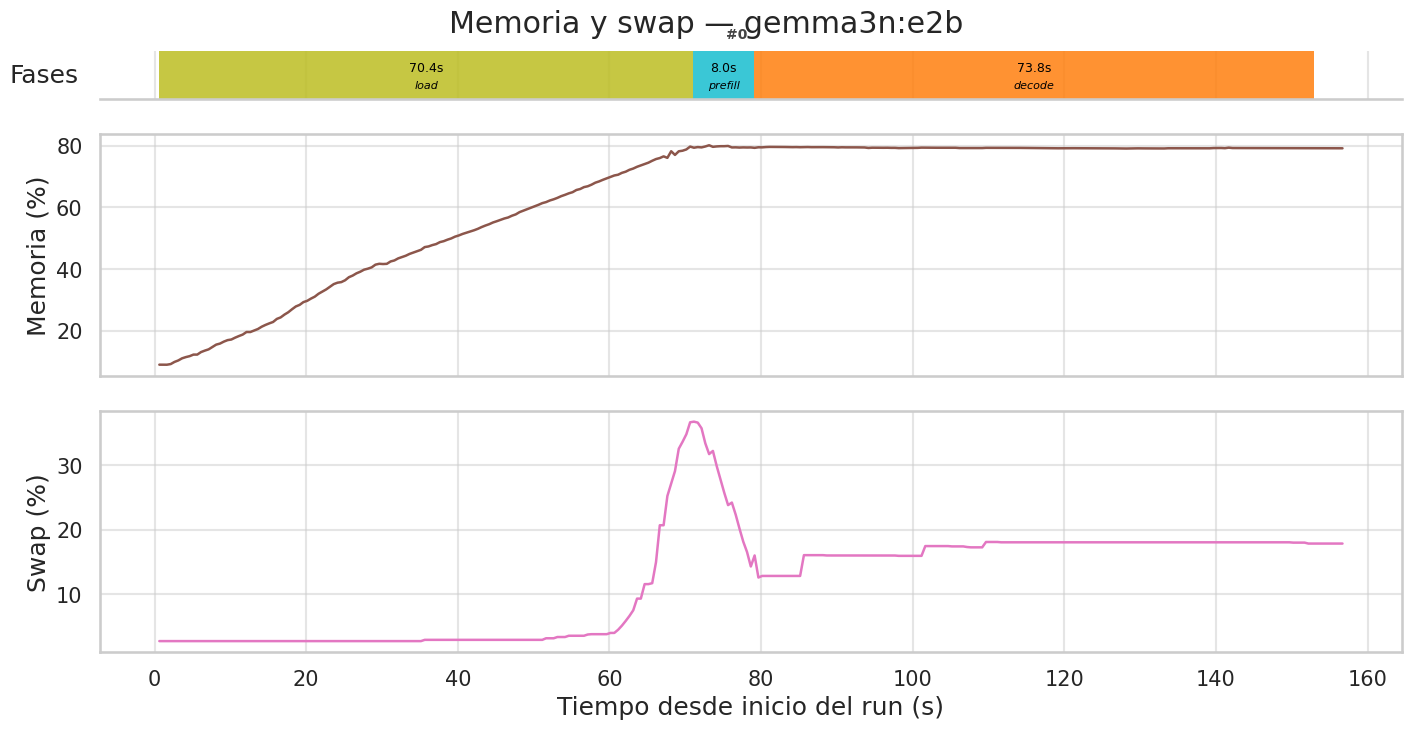

In [6]:
if SHOW_MEMORY and not hw_df.empty:
    fig = memory_timeline(
        hw_df, prompt_df,
        title=f"Memoria y swap — {run.model_short}",
    )
    plt.show()
elif hw_df.empty:
    print("Sin datos de hardware: memoria omitida.")
else:
    print("Memoria desactivada.")

## 6. Correlaciones (doble eje Y)

Dos pares de métricas que suelen correlacionar fuerte. Verlas en el mismo
eje X con escalas independientes ayuda a confirmar (o descartar) hipótesis
sobre el comportamiento térmico.

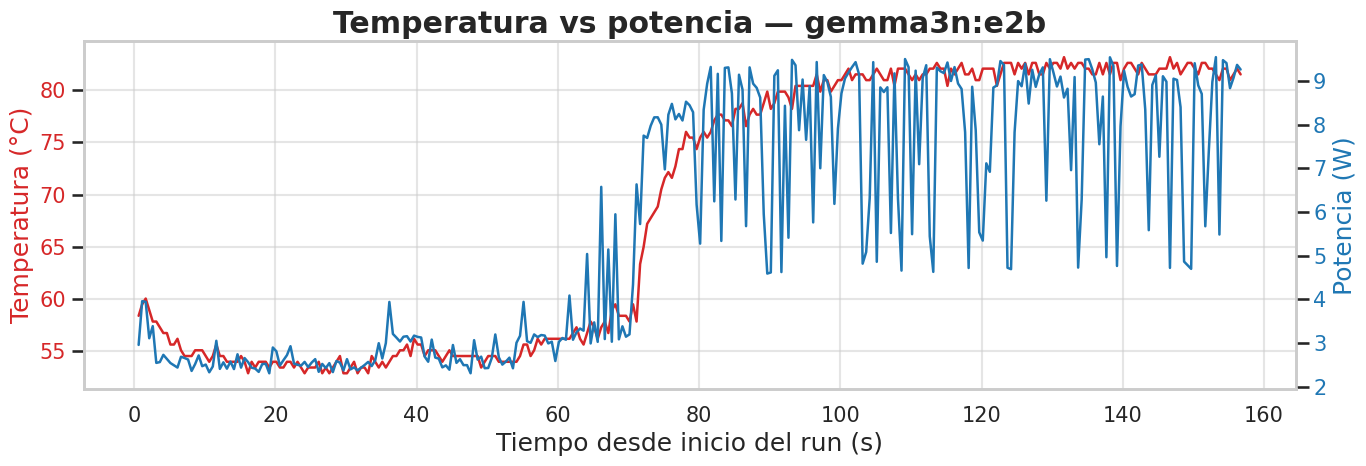

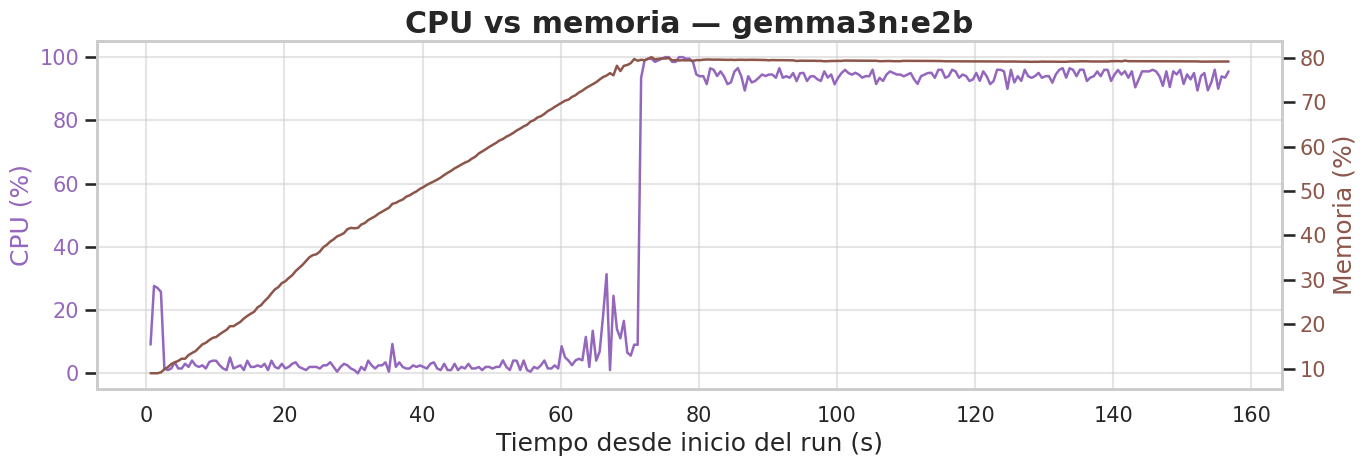

In [7]:
if SHOW_DUAL_AXIS and not hw_df.empty:
    fig = temp_power_dual(
        hw_df,
        title=f"Temperatura vs potencia — {run.model_short}",
    )
    plt.show()

    fig = cpu_memory_dual(
        hw_df,
        title=f"CPU vs memoria — {run.model_short}",
    )
    plt.show()
elif hw_df.empty:
    print("Sin datos de hardware: correlaciones omitidas.")

## 7. Frecuencia por núcleo

La RPi5 tiene 4 cores. En modelos cuantizados ejecutándose en CPU es
habitual ver los 4 cores a su frecuencia máxima de forma sostenida (poco
margen de DVFS). Si algún core baja la frecuencia, suele coincidir con
eventos de throttling. (TOdos los cores van a la misma frecuencia)

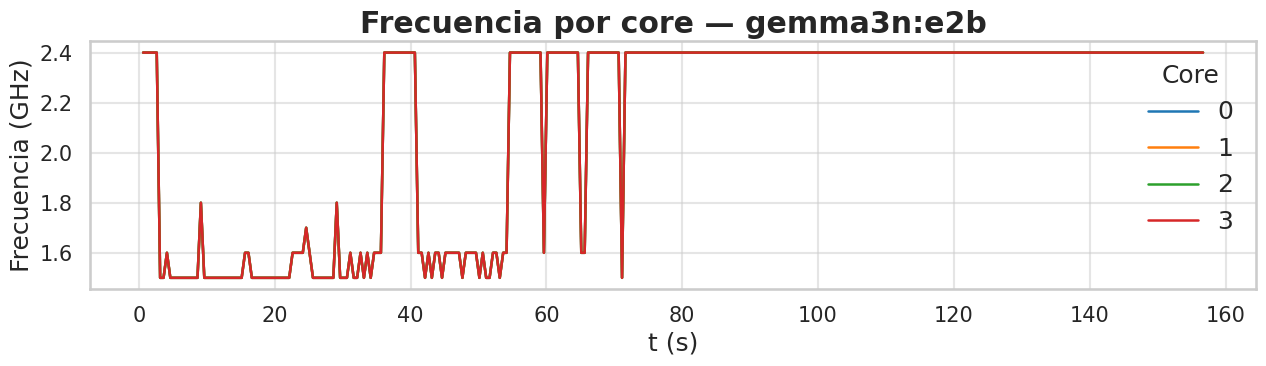

In [8]:
if SHOW_PER_CORE_FREQ and not hw_df.empty:
    freq_long = hw_freq_long(run)
    fig = hw_freq_panel(
        freq_long,
        title=f"Frecuencia por core — {run.model_short}",
    )
    plt.show()
elif hw_df.empty:
    print("Sin datos de hardware: per-core omitido.")

## 8. Métricas de inferencia por prompt

Latencia, throughput y perplejidad para cada prompt del run.

**Notas metodológicas**:
- La perplejidad mide la "sorpresa" del modelo sobre los tokens que él
  mismo generó. Valores cercanos a 1 indican alta confianza
  (esperable con `temperature=0`); valores altos indican respuestas más
  inseguras.
- `tokens_per_second` y `words_per_second` no son intercambiables entre
  modelos con tokenizers distintos: los tokens varían en longitud según el
  vocabulario.
- Prompts marcados con `is_empty_generation` (modelos base no
  instruction-tuned) no aparecen en estas gráficas.

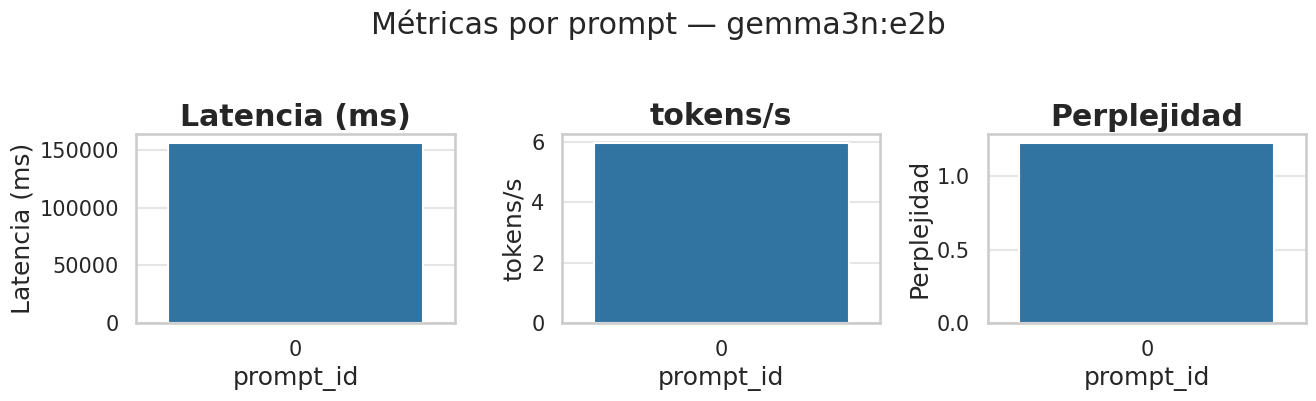

In [14]:
if SHOW_DISTRIBUTIONS:
    non_empty = prompt_df[~prompt_df["is_empty_generation"]]
    if non_empty.empty:
        print("Todos los prompts son generaciones vacías; nada que graficar.")
    else:
        fig = inference_summary_panel(
            non_empty,
            title=f"Métricas por prompt — {run.model_short}",
        )
        plt.show()

## 9. Confianza del modelo a lo largo de la respuesta

Cada línea es un prompt; el eje X es la posición del token dentro de la
respuesta y el eje Y el log-probabilidad asignado por el modelo a ese
token. Cuanto más cercano a 0, más seguro estaba el modelo.

Solo está disponible para runs OLLAMA con respuesta no vacía (LLAMA solo
proporciona la probabilidad bruta sin texto del token).

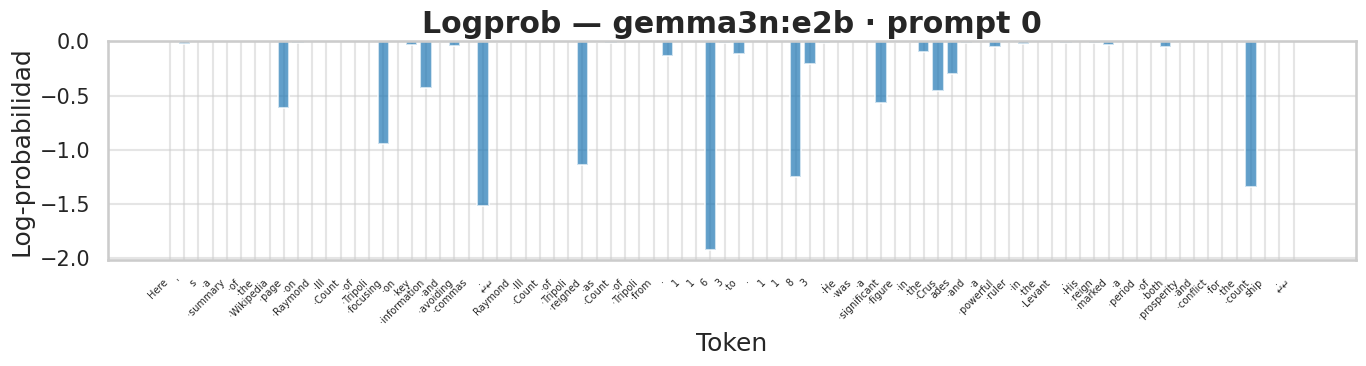

In [10]:
if SHOW_LOGPROB:
    non_empty_prompts = [p for p in run.prompts if not p.is_empty_generation and p.tokens]
    if not non_empty_prompts:
        print("No hay logprobs disponibles (todos los prompts vacíos).")
    else:
        for p in non_empty_prompts[:3]:
            fig = logprob_panel(
                p.tokens,
                prompt_id=p.prompt_id,
                title=f"Logprob — {run.model_short} · prompt {p.prompt_id}",
            )
            plt.show()
else:
    print("Logprob desactivado.")

## 10. Resumen

Esta sección resume los hallazgos del análisis para integración directa en
la memoria del TFG.

In [13]:
non_empty = prompt_df[~prompt_df["is_empty_generation"]]

summary_lines = [
    f"Run: {run.run_id}",
    f"Motor: {run.summary.inference_engine}, modelo: {run.model_short}",
    f"Duración total: {duration_s:.1f} s ({len(prompt_df)} prompts).",
]

if not non_empty.empty:
    summary_lines.append(
        f"Latencia media por prompt: {non_empty['latency_ms'].mean() / 1000:.1f} s "
        f"(p95: {non_empty['latency_ms'].quantile(0.95) / 1000:.1f} s)."
    )
    summary_lines.append(
        f"Throughput medio: {non_empty['tokens_per_second'].mean():.2f} tokens/s "
        f"({non_empty['words_per_second'].mean():.2f} palabras/s)."
    )
    if non_empty["perplexity"].notna().any():
        summary_lines.append(
            f"Perplejidad media: {non_empty['perplexity'].mean():.2f}."
        )

n_empty = int(prompt_df["is_empty_generation"].sum())
if n_empty:
    summary_lines.append(
        f"⚠️  {n_empty}/{len(prompt_df)} prompts con generación vacía "
        "(modelos base no instruction-tuned)."
    )

if not hw_df.empty:
    summary_lines.append(
        f"Temperatura: media {hw_df['temperature_c'].mean():.1f} °C, "
        f"máx {hw_df['temperature_c'].max():.1f} °C."
    )
    summary_lines.append(
        f"Potencia: media {hw_df['internal_power_w'].mean():.2f} W, "
        f"máx {hw_df['internal_power_w'].max():.2f} W."
    )
    n_throttled = int(hw_df["throt_any_active"].sum())
    if n_throttled:
        ratio = n_throttled / len(hw_df) * 100
        summary_lines.append(
            f"⚠️  {n_throttled}/{len(hw_df)} muestras con throttling activo "
            f"({ratio:.1f}% del run)."
        )
    else:
        summary_lines.append("Sin throttling durante el run.")

print("\n".join(summary_lines))

Run: gemma
Motor: OLLAMA, modelo: gemma3n:e2b
Duración total: 157.2 s (1 prompts).
Latencia media por prompt: 156.2 s (p95: 156.2 s).
Throughput medio: 5.97 tokens/s (4.71 palabras/s).
Perplejidad media: 1.23.
Temperatura: media 68.7 °C, máx 83.2 °C.
Potencia: media 5.66 W, máx 9.55 W.
⚠️  68/313 muestras con throttling activo (21.7% del run).
